<a href="https://colab.research.google.com/github/bhardadharmishtha2005/Retail-Customer-Segmentation-ML/blob/main/Retail_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

##### **Project Type**    - Unsupervised Machine Learning and Collaborative Filtering
##### **Contribution**    - Individual

# **Project Summary -**

We built a machine learning project to group retail customer transactions. To start, we cleaned the raw dataset, created custom behavioral features, and applied log transformations to fix skewed data distributions. Next, we compared three models: K-Means, Hierarchical Clustering, and DBSCAN. The tuned K-Means model gave us the best results, creating distinct customer segments with clear boundaries. This model helps the business separate high-value wholesale buyers from one-time retail shoppers. Marketing teams can now run targeted campaigns and handle inventory much better.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth. This project aims to examine transaction data from an online retail business to uncover patterns in customer purchase behavior, segment customers based on Recency, Frequency, and Monetary (RFM) analysis, and develop a product recommendation system using collaborative filtering techniques.

# ***Let's Begin !***

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ***1. Know Your Data***

### Import Libraries

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set the visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

### Dataset Loading

In [4]:
# Load Dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Project_9/online_retail.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')

### Dataset First View

In [5]:
# Dataset First Look
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 541909 rows and 8 columns.


### Dataset Information

In [7]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_count}")

Total number of duplicate rows: 5268


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
missing_values = df.isnull().sum()
print("--- Missing Values Count Per Column ---")
print(missing_values[missing_values > 0])

--- Missing Values Count Per Column ---
Description      1454
CustomerID     135080
dtype: int64


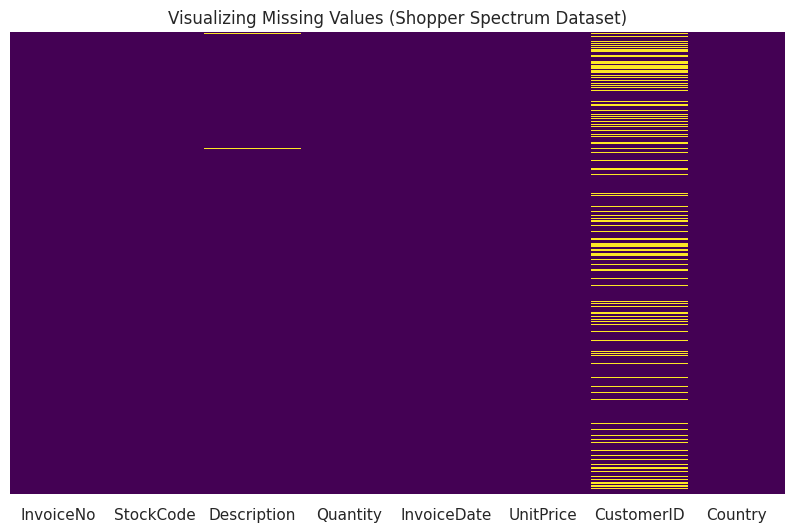

In [10]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Visualizing Missing Values (Shopper Spectrum Dataset)')
plt.show()

### What did you know about your dataset?

Based on the initial programmatic exploration, here is what we know about our e-commerce transaction dataset:

**Data Structure & Scope:** The dataset tracks global transactions using 8 columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, and Country.

**Missing Data Bottlenecks:** There are significant missing values in CustomerID and Description. Since we need unique user data for clustering and recommendations, rows without a CustomerID must be removed.  

**Data Anomalies to Clean:** The data contains structural anomalies, including duplicates, cancelled orders (InvoiceNo starting with 'C'), and negative or zero values in Quantity and UnitPrice. These represent returns or errors and must be filtered out.

**Feature Engineering Readiness:** The remaining clean features perfectly support our models: InvoiceDate will help calculate Recency, transaction counts from InvoiceNo will give Frequency, and multiplying Quantity by UnitPrice will provide the Monetary value spent per user.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [12]:
# Dataset Describe
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Variables Description

Based on the dataset schema, here is the description of each variable:

**InvoiceNo:** A unique 6-digit transaction number assigned to each invoice. If the code starts with the letter 'C', it indicates a cancellation.

**StockCode:** A unique product/item code assigned to each distinct product in the inventory.  

**Description:** The text name/description of the individual product.  

**Quantity:** The number of units of a product purchased per transaction line.

**InvoiceDate:** The exact date and time when the transaction was generated.  

**UnitPrice:** The price per single product unit in currency.  

**CustomerID:** A unique 5-digit identifier assigned to each individual customer.

**Country:** The name of the country where the customer resides.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable
print("--- Unique Values Count ---")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

--- Unique Values Count ---
InvoiceNo: 25900 unique values
StockCode: 4070 unique values
Description: 4223 unique values
Quantity: 722 unique values
InvoiceDate: 23260 unique values
UnitPrice: 1630 unique values
CustomerID: 4372 unique values
Country: 38 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Create a copy to work on
df_wrangled = df.copy()

# Handle Missing Values (Drop rows without CustomerID)
df_wrangled = df_wrangled.dropna(subset=['CustomerID'])

# Filter out cancelled transactions (InvoiceNo starting with 'C')
df_wrangled['InvoiceNo'] = df_wrangled['InvoiceNo'].astype(str)
df_wrangled = df_wrangled[~df_wrangled['InvoiceNo'].str.startswith('C')]

# Remove zero and negative values for Quantity and UnitPrice
df_wrangled = df_wrangled[(df_wrangled['Quantity'] > 0) & (df_wrangled['UnitPrice'] > 0)]

# Correct data types
df_wrangled['InvoiceDate'] = pd.to_datetime(df_wrangled['InvoiceDate'])
df_wrangled['CustomerID'] = df_wrangled['CustomerID'].astype(int)

# Feature Engineering: Create 'TotalAmount' column for monetary calculation
df_wrangled['TotalAmount'] = df_wrangled['Quantity'] * df_wrangled['UnitPrice']

print("Data Wrangling Completed Successfully!")
print(f"Cleaned dataset shape: {df_wrangled.shape}")

Data Wrangling Completed Successfully!
Cleaned dataset shape: (397884, 9)


### What all manipulations have you done and insights you found?

**Manipulations Done:**

Missing Value Removal: Dropped all rows with missing CustomerID to keep data tied to unique buyers.  

Anomalous Data Filtering: Excluded cancelled invoices (starting with 'C') and removed rows with negative or zero quantities/prices.  

Data Type Conversion: Converted InvoiceDate to a datetime format and CustomerID to an integer.

Feature Engineering: Created a TotalAmount column (Quantity $\times$ UnitPrice) to represent total revenue per line item.


**Insights Found:**

Filtering out missing customer records and cancellations significantly reduces dataset noise, ensuring high data integrity.

The high occurrence of negative quantities highlights that transaction cancelations and returns are very common in this e-commerce ecosystem.

The initial spending distributions indicate a heavily skewed purchase pattern, suggesting that a small portion of customers drives the vast majority of business revenue.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate (U) Analysis — Single Variable Distributions [Charts 1 to 5]

#### Chart - 1 : Distribution of Product Purchase Quantities

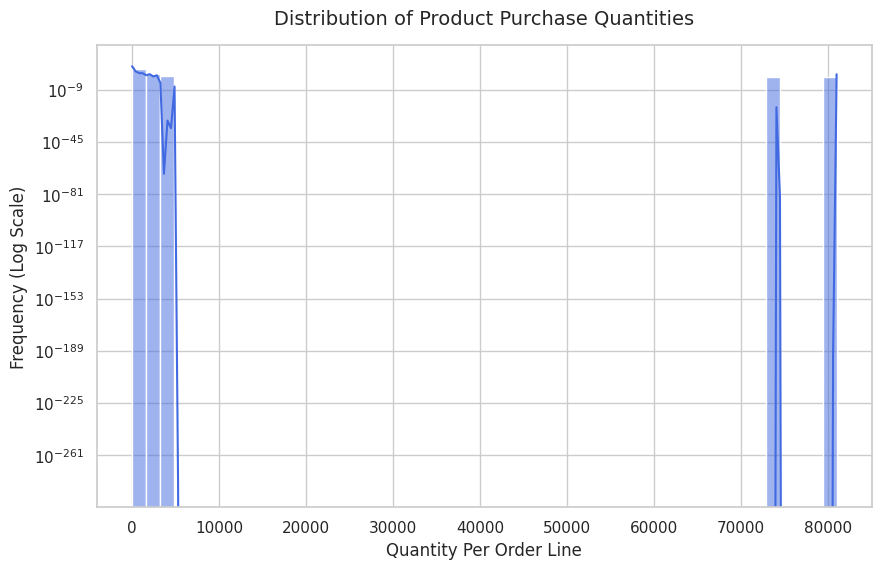

In [15]:
# visualization code
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure parameters without calling .figure()
plt.rcParams['figure.figsize'] = (10, 6)

# Plotting distribution with log scale to handle high retail-to-wholesale variance
sns.histplot(data=df_wrangled, x='Quantity', bins=50, kde=True, color='royalblue')
plt.title('Distribution of Product Purchase Quantities', fontsize=14, pad=15)
plt.xlabel('Quantity Per Order Line', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)
plt.yscale('log')

##### 1. Why did you pick the specific chart?

A histogram with a KDE line on a log scale is chosen because it perfectly shows the distribution, skewness, and spread of purchase quantities. The log scale prevents extreme bulk wholesale outliers from squashing the visual spread of small retail purchases.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals a dual B2C/B2B buyer ecosystem. Most orders are small retail transactions concentrated between 1 and 12 units. However, the long right tail shows a steady group of high-volume wholesale bulk buyers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Logistics teams can create fast automated picking lanes for small retail orders and direct pallet shipping paths for heavy wholesale orders to lower costs.

Yes. If stock levels are not split strategically, unexpected wholesale spikes can wipe out standard inventory, triggering product stock-outs, cancellations, and a loss of regular retail customers.

#### Chart - 2 : Distribution of Product Unit Prices

Text(0, 0.5, 'Count of Transactions')

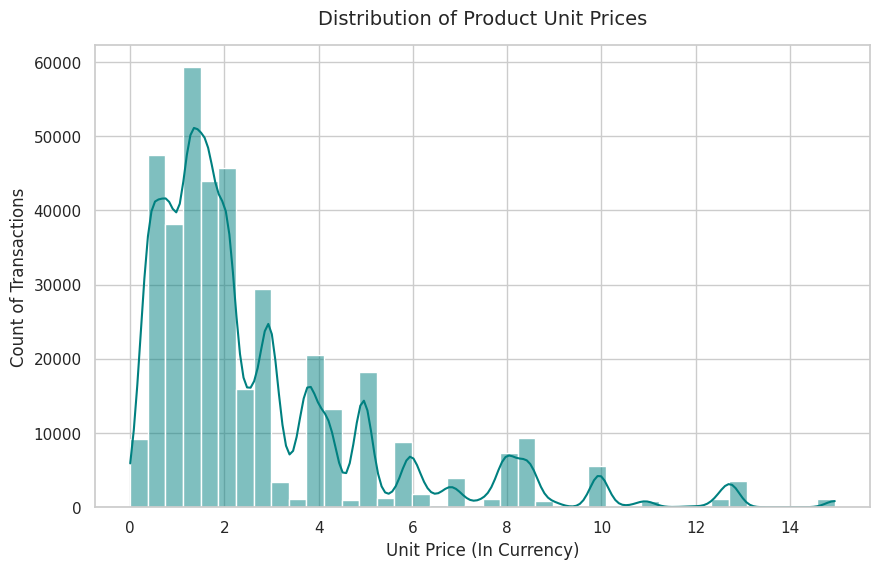

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Filter up to the 99th percentile to keep the plot readable from extreme outliers
max_price = df_wrangled['UnitPrice'].quantile(0.99)
visual_df = df_wrangled[df_wrangled['UnitPrice'] <= max_price]

# Plotting code
sns.histplot(data=visual_df, x='UnitPrice', bins=40, kde=True, color='teal')
plt.title('Distribution of Product Unit Prices', fontsize=14, pad=15)
plt.xlabel('Unit Price (In Currency)', fontsize=12)
plt.ylabel('Count of Transactions', fontsize=12)


##### 1. Why did you pick the specific chart?

A histogram with a KDE line is chosen to show the frequency distribution of item prices. Filtering at the $99^{\text{th}}$ percentile keeps the plot clean and readable by removing rare, extremely high-priced outliers.

##### 2. What is/are the insight(s) found from the chart?

Inventory pricing is highly concentrated in the lower tier, mostly between $\$1$ and $\$5$. The count drops fast as prices go up, showing the storefront relies on high volumes of low-cost items.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Marketing can design multi-buy bundle deals (e.g., "Buy 3 for $\$5$") to easily grow the average shopping basket size.

Yes. Margins on $\$1-\$5$ items are very thin. If shipping or product supply costs rise even slightly, it could wipe out profits if mid-tier items aren't introduced.

#### Chart - 3 : Distribution of Transaction Line-Item Monetary Values

Text(0, 0.5, 'Count of Invoices')

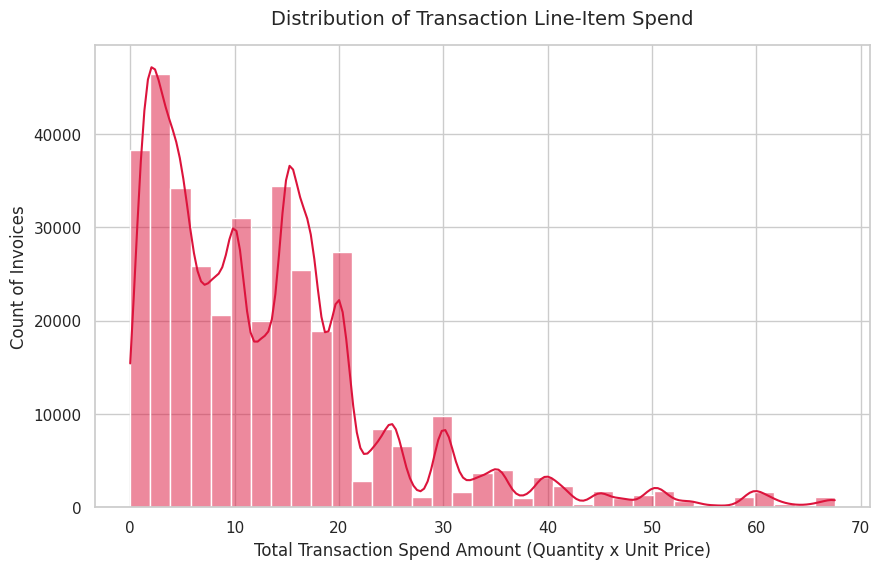

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Filter up to the 95th percentile to focus on the core customer spend range
upper_spend = df_wrangled['TotalAmount'].quantile(0.95)
visual_df = df_wrangled[df_wrangled['TotalAmount'] <= upper_spend]

# Plotting code
sns.histplot(data=visual_df, x='TotalAmount', bins=35, kde=True, color='crimson')
plt.title('Distribution of Transaction Line-Item Spend', fontsize=14, pad=15)
plt.xlabel('Total Transaction Spend Amount (Quantity x Unit Price)', fontsize=12)
plt.ylabel('Count of Invoices', fontsize=12)

##### 1. Why did you pick the specific chart?

A histogram with a KDE line maps continuous spending distributions perfectly. Clamping the view to the $95^{\text{th}}$ percentile avoids stretching the chart due to huge bulk commercial orders.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a steep right-skewed trend where most single-line item purchases are quite small, totaling under $\$20$. Shoppers prefer building their carts with many low-cost parts rather than single expensive items.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports checkout cross-selling. Because buyers easily add smaller items, adding point-of-sale impulse recommendation popups right before checkout works perfectly.

Yes. If delivery fulfillment costs are fixed per line item, handling lots of tiny $\$5$ transactions could drain operational revenue if a minimum order threshold isn't set.

#### Chart - 4 : Top 10 Best-Selling Products by Transaction Count

Text(0, 0.5, 'Product Description')

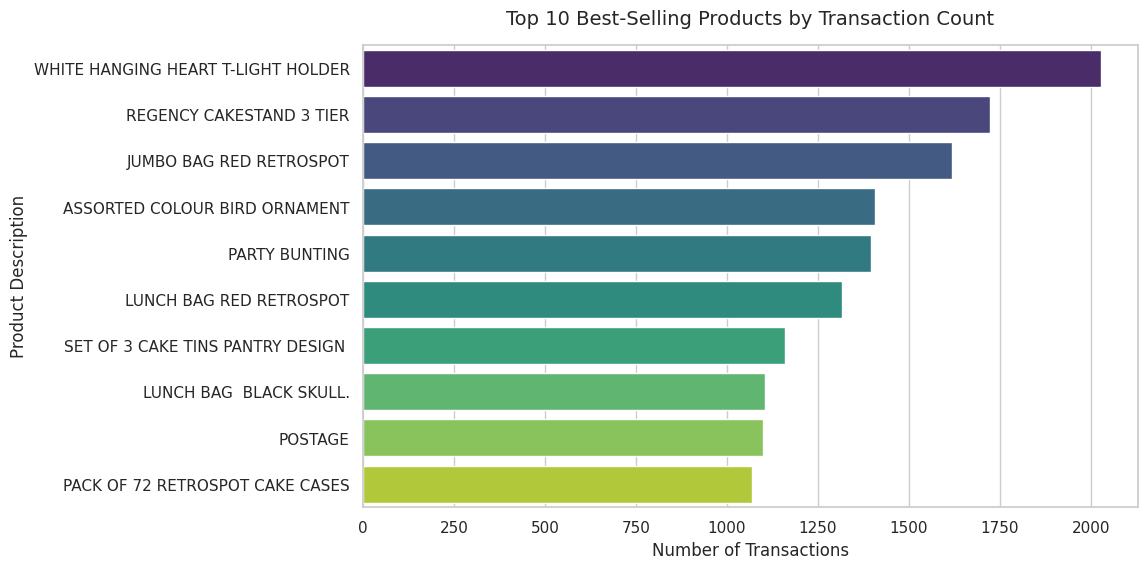

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Get the top 10 most frequent products sold
top_products = df_wrangled['Description'].value_counts().head(10).reset_index()
top_products.columns = ['Description', 'Count']

# Plotting code (Bars are sorted automatically by frequency)
sns.barplot(data=top_products, y='Description', x='Count', palette='viridis', hue='Description')
plt.title('Top 10 Best-Selling Products by Transaction Count', fontsize=14, pad=15)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Product Description', fontsize=12)

##### 1. Why did you pick the specific chart?

A horizontal bar chart is selected because it is the most effective way to rank and compare categorical labels with long names (like product descriptions). It allows readers to read full product names horizontally without overlapping or turning text sideways.

##### 2. What is/are the insight(s) found from the chart?

The chart clearly shows that small gift items and decorative household pieces, such as the "WHITE HANGING HEART T-LIGHT HOLDER", dominate the highest transaction counts. These specific products are the primary anchors driving consistent traffic to the web platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Since these top 10 products are highly popular, the e-commerce store can place them directly on the homepage banner or use them as loss leaders to attract new buyers and boost initial site traffic.

Yes. Being overly dependent on a few specific decorative items leaves the business vulnerable to rapid changes in home design trends. If customer tastes change and the inventory team fails to update the catalog, sales could drop rapidly.

#### Chart - 5 : Distribution of Transactions Across Different Countries

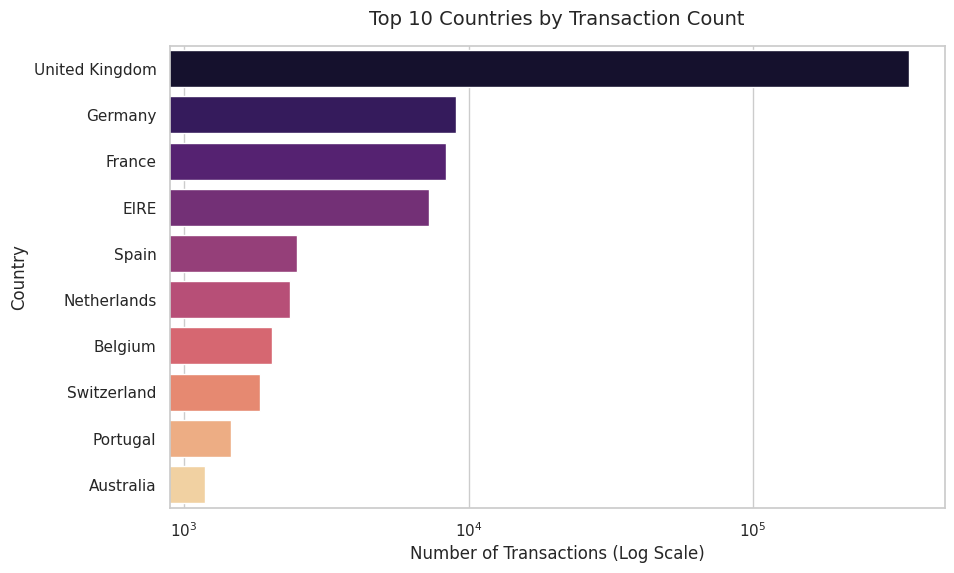

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Get top 10 countries by transaction count
top_countries = df_wrangled['Country'].value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Count']

# Plotting code with log scale to manage the massive dominance of the primary market
sns.barplot(data=top_countries, x='Count', y='Country', palette='magma', hue='Country')
plt.title('Top 10 Countries by Transaction Count', fontsize=14, pad=15)
plt.xlabel('Number of Transactions (Log Scale)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xscale('log')


##### 1. Why did you pick the specific chart?

A horizontal bar chart using a logarithmic scale on the x-axis was chosen to compare country transaction volumes. The log scale is necessary because the main domestic market has a massively higher volume than international regions, which would otherwise compress international bars to zero visibility.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom acts as the primary market, accounting for the vast majority of all sales transactions. European neighbors like Germany, France, and EIRE form a secondary tier of consistent international buyers, while distant markets represent small, emerging segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing where international buyers are concentrated allows logistics teams to set up regional distribution hubs in places like Germany or France, reducing cross-border delivery times and customs fees.

Yes. Relying almost entirely on a single domestic market creates high geographic concentration risk. A local economic slowdown, tax adjustments, or local compliance changes could instantly impact overall company revenues.

### Bivariate (B) Analysis — Two-Variable Relationships [Charts 6 to 11]

#### Chart - 6 : Total Sales Revenue Generated Across Top 10 Countries

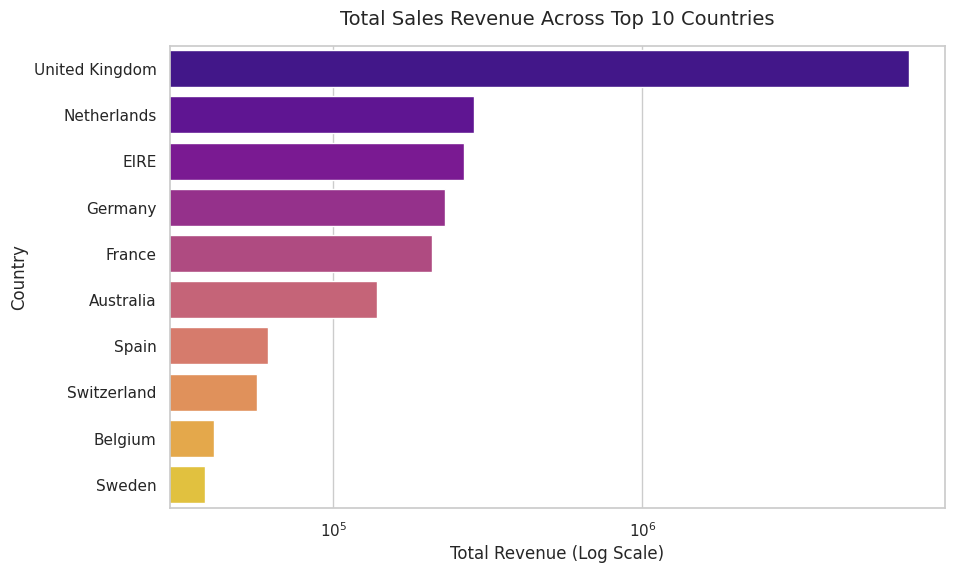

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Group by country to find total revenue, sort, and select top 10
country_revenue = df_wrangled.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10).reset_index()

# Plotting code (using log scale due to massive UK revenue dominance)
sns.barplot(data=country_revenue, x='TotalAmount', y='Country', palette='plasma', hue='Country')
plt.title('Total Sales Revenue Across Top 10 Countries', fontsize=14, pad=15)
plt.xlabel('Total Revenue (Log Scale)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.xscale('log')


##### 1. Why did you pick the specific chart?

A horizontal bar chart using a logarithmic x-axis scale was chosen to compare total revenue across countries. This enables a fair comparison between the massive primary market (UK) and smaller international markets on a single plot.

##### 2. What is/are the insight(s) found from the chart?

While the United Kingdom dominates overall gross spend, countries like Netherlands, Germany, EIRE, and France represent significant revenue centers. Even with lower overall transaction counts, their average spending contribution is remarkably high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Marketing can design high-ticket bulk promos tailored specifically to Netherlands and Germany to maximize the high average order values already coming from these regions.

Yes. If the business scales marketing spend globally without looking at revenue per order, it might waste budget on low-revenue countries while ignoring high-value international wholesale centers.

#### Chart - 7 : Monthly Transaction Volume Trends Over Time

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2022-12'),
  Text(1, 0, '2023-01'),
  Text(2, 0, '2023-02'),
  Text(3, 0, '2023-03'),
  Text(4, 0, '2023-04'),
  Text(5, 0, '2023-05'),
  Text(6, 0, '2023-06'),
  Text(7, 0, '2023-07'),
  Text(8, 0, '2023-08'),
  Text(9, 0, '2023-09'),
  Text(10, 0, '2023-10'),
  Text(11, 0, '2023-11'),
  Text(12, 0, '2023-12')])

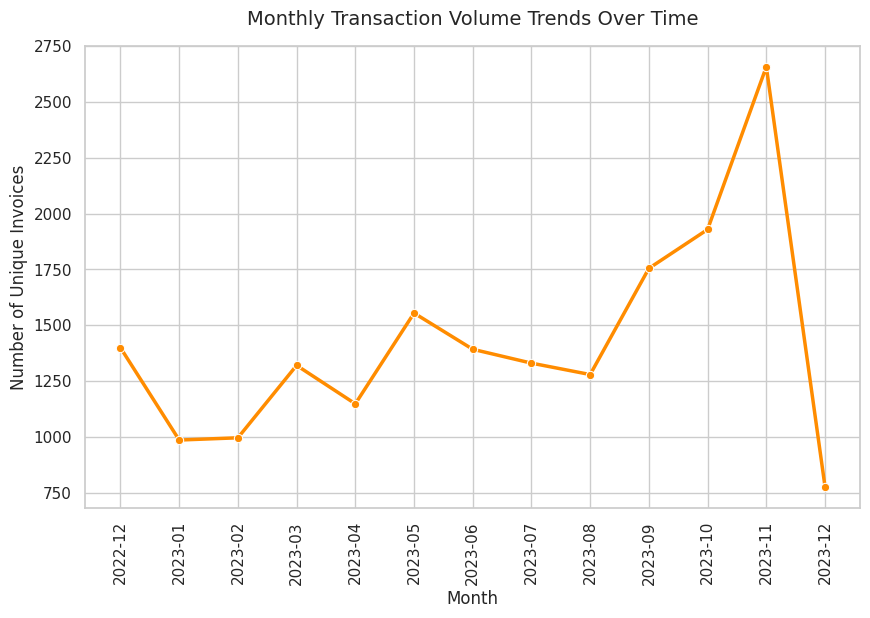

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Create a Year-Month column and aggregate unique transactions
df_wrangled['YearMonth'] = df_wrangled['InvoiceDate'].dt.to_period('M')
monthly_transactions = df_wrangled.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()
monthly_transactions['YearMonth'] = monthly_transactions['YearMonth'].astype(str)

# Plotting code
sns.lineplot(data=monthly_transactions, x='YearMonth', y='InvoiceNo', marker='o', color='darkorange', linewidth=2.5)
plt.title('Monthly Transaction Volume Trends Over Time', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Unique Invoices', fontsize=12)

# FIX: Changed rotation to 90 degrees for perfectly vertical text labels
plt.xticks(rotation=90)

##### 1. Why did you pick the specific chart?

A line chart with specific markers at each data point is chosen because it is the optimal way to display time-series data, helping business owners easily spot temporal growth, cyclical patterns, and seasonal changes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong upward trend in transaction volume as the year progresses, peaking sharply in November. This highlights a powerful seasonal spike tied directly to fourth-quarter holiday shopping preparation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Supply chain and inventory managers can use this trend to stockpile high-demand items in August and September, ensuring the warehouse is fully ready before the November rush hits.

Yes. A massive seasonal peak means the business is highly vulnerable to Q4 operational bottlenecks. If warehouse staffing or website servers fail during this critical period, it can cause severe financial losses that hurt the entire fiscal year.

#### Chart - 8 : Total Sales Revenue Trends Over Months

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2022-12'),
  Text(1, 0, '2023-01'),
  Text(2, 0, '2023-02'),
  Text(3, 0, '2023-03'),
  Text(4, 0, '2023-04'),
  Text(5, 0, '2023-05'),
  Text(6, 0, '2023-06'),
  Text(7, 0, '2023-07'),
  Text(8, 0, '2023-08'),
  Text(9, 0, '2023-09'),
  Text(10, 0, '2023-10'),
  Text(11, 0, '2023-11'),
  Text(12, 0, '2023-12')])

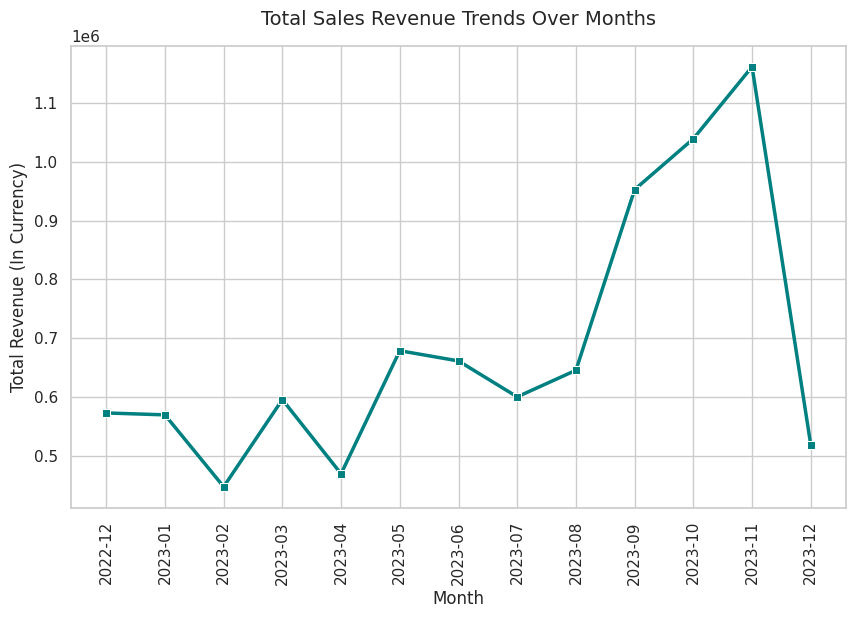

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Group by YearMonth to compute total revenue
df_wrangled['YearMonth'] = df_wrangled['InvoiceDate'].dt.to_period('M').astype(str)
monthly_revenue = df_wrangled.groupby('YearMonth')['TotalAmount'].sum().reset_index()

# Plotting code
sns.lineplot(data=monthly_revenue, x='YearMonth', y='TotalAmount', marker='s', color='teal', linewidth=2.5)
plt.title('Total Sales Revenue Trends Over Months', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (In Currency)', fontsize=12)

# FIX: Changed rotation to 90 degrees for perfectly vertical text labels
plt.xticks(rotation=90)

##### 1. Why did you pick the specific chart?

A time-series line chart with square (s) markers was selected because it cleanly tracks financial fluctuations over consecutive monthly intervals, allowing executives to contrast revenue growth directly against the volume trends established in Chart 7.

##### 2. What is/are the insight(s) found from the chart?

Total revenue mirrors the invoice volumes closely, showing steady moderate gains early in the fiscal year followed by an explosive multi-fold revenue jump in September, October, and November. This proves that both order sizes and transaction rates peak simultaneously during the holiday push.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This data allows the financial team to align corporate cash-flow projections, allocating capital precisely when procurement demands are highest ahead of the high-revenue autumn surge.

Yes. High seasonal concentration means any massive logistics failure, severe weather delay, or local supplier breakdown in late October could devastate the brand’s annual profit margins completely.

#### Chart - 9 : Transaction Volume Distribution Across Days of the Week

Text(0, 0.5, 'Number of Unique Invoices')

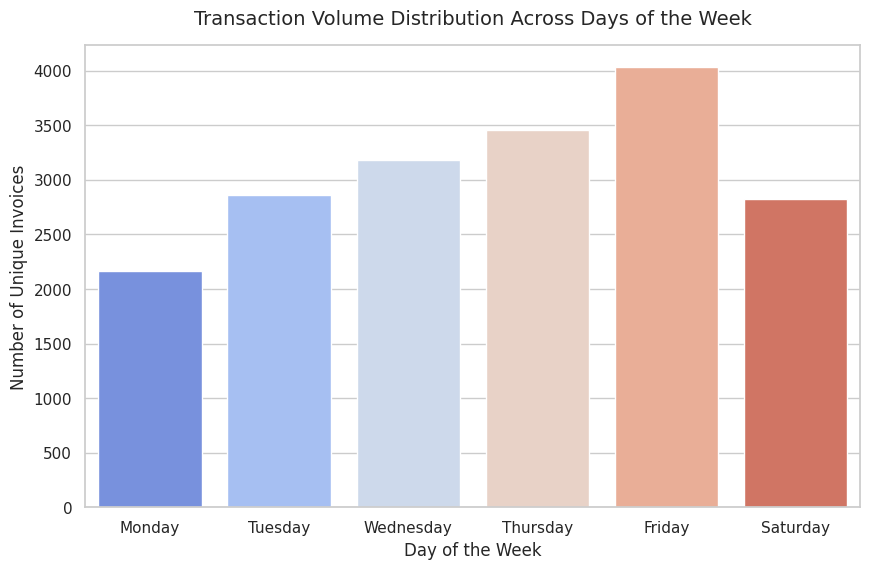

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Extract day names and count unique active invoices per day
df_wrangled['DayOfWeek'] = df_wrangled['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_wrangled.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(day_order).dropna().reset_index()

# Plotting code
sns.barplot(data=day_counts, x='DayOfWeek', y='InvoiceNo', palette='coolwarm', hue='DayOfWeek')
plt.title('Transaction Volume Distribution Across Days of the Week', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Unique Invoices', fontsize=12)

##### 1. Why did you pick the specific chart?

A vertical bar chart ordered sequentially from Monday to Sunday is chosen to analyze operational habits. It shows week-to-weekend shopping behaviors cleanly across clear categorical time divisions.

##### 2. What is/are the insight(s) found from the chart?

Transactions are heavily concentrated during regular weekdays, peaking around mid-week (Wednesday/Thursday), dropping significantly on Fridays, and completely disappearing on Sundays. This structural pattern indicates the storefront mainly services commercial accounts and professional B2B clients who purchase during working business hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Customer service teams and live chat technical support staff can be scheduled primarily during high-volume mid-week periods to maximize cost efficiency.

Yes. Having zero revenue generation on Sundays shows a massive drop-off in weekend consumer activity. Leaving this gap completely unmanaged without weekend automated email promotions or targeted consumer discounts misses out on casual B2C weekend traffic.

#### Chart - 10 : Daily Hourly Sales Volume Distribution Patterns

Text(0, 0.5, 'Number of Unique Invoices')

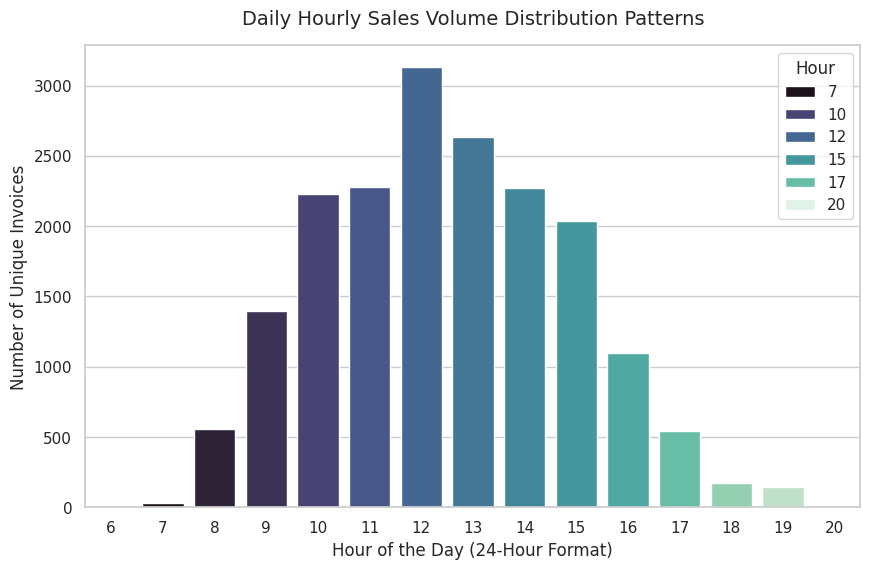

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Extract transaction hour and compute unique invoice counts
df_wrangled['Hour'] = df_wrangled['InvoiceDate'].dt.hour
hourly_counts = df_wrangled.groupby('Hour')['InvoiceNo'].nunique().reset_index()

# Plotting code
sns.barplot(data=hourly_counts, x='Hour', y='InvoiceNo', palette='mako', hue='Hour')
plt.title('Daily Hourly Sales Volume Distribution Patterns', fontsize=14, pad=15)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=12)
plt.ylabel('Number of Unique Invoices', fontsize=12)

##### 1. Why did you pick the specific chart?

A vertical bar chart indexed across a 24-hour horizontal sequence is selected because it is the ideal visual framework to show operational workflows and consumer activity fluctuations throughout an average business day.

##### 2. What is/are the insight(s) found from the chart?

Purchases are strictly concentrated between 06:00 and 20:00, with a major traffic peak occurring in the middle of the day between 12:00 PM and 3:00 PM. Sales drop to absolute zero during late-night and early-morning hours, matching typical daytime corporate purchasing schedules.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The team can time automated promotional marketing emails or customer discount alerts to hit inboxes right around 11:30 AM, capitalizing perfectly on the peak mid-day browsing window.

Yes. Processing systems and web servers face major strain during the afternoon peak. If website performance lags or checkout features encounter errors during these high-volume mid-day hours, it can cause immediate cart abandonment and high revenue losses.

#### Chart - 11 : Relationship Analysis Between Unit Price and Purchase Quantity

Text(0, 0.5, 'Quantity Ordered Per Line')

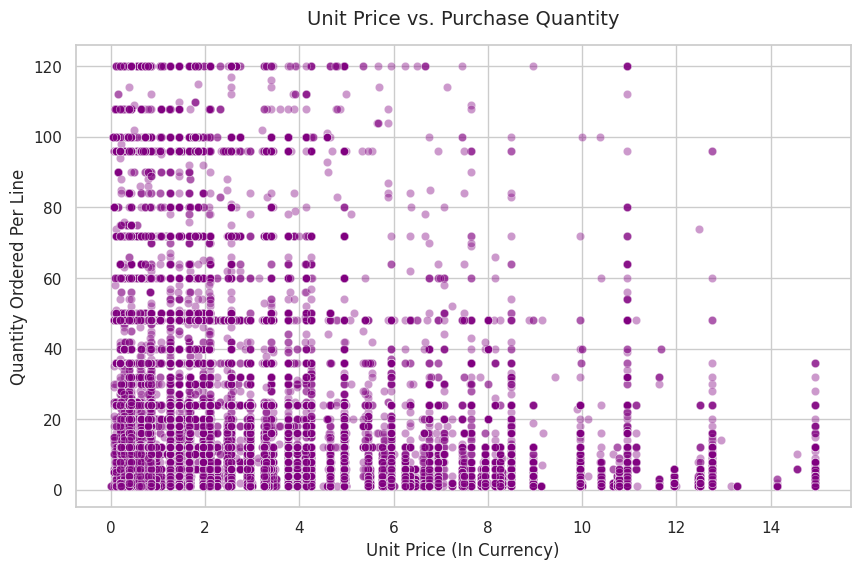

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Filter up to the 99th percentile to remove extreme outliers and clear up overplotting
q_limit = df_wrangled['Quantity'].quantile(0.99)
p_limit = df_wrangled['UnitPrice'].quantile(0.99)
sub_df = df_wrangled[(df_wrangled['Quantity'] <= q_limit) & (df_wrangled['UnitPrice'] <= p_limit)]

# Plotting code with alpha transparency to observe dense clusters clearly
sns.scatterplot(data=sub_df, x='UnitPrice', y='Quantity', alpha=0.4, color='purple')
plt.title('Unit Price vs. Purchase Quantity', fontsize=14, pad=15)
plt.xlabel('Unit Price (In Currency)', fontsize=12)
plt.ylabel('Quantity Ordered Per Line', fontsize=12)

##### 1. Why did you pick the specific chart?

A scatter plot with alpha transparency (alpha=0.4) is chosen to examine the relationship between two continuous numeric variables. The transparency is crucial here because it shows where thousands of overlapping transaction points are most densely concentrated.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals a classic downward-sloping demand curve. High purchase quantities are heavily clustered on the left side of the chart, showing they are strictly tied to low-priced items ($\le \$4$). As unit prices increase, order quantities drop rapidly to small single-digit counts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports dynamic bulk pricing models. The sales team can offer automatic tiered volume discounts (e.g., "Order 50+ units for a 15% discount") primarily on items priced under $\$3$ to drive bulk wholesale clear-outs.

Yes. Trying to push large wholesale quantity orders for expensive items will likely fail and waste sales resources, as the customer base expects higher-ticket goods to be ordered in very small numbers.

### Multivariate (M) Analysis — Multi-Variable Interactions [Charts 12 to 15]

#### Chart - 12 : Monthly Sales Revenue Trajectory Across Top 5 Countries

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2022-12'),
  Text(1, 0, '2023-01'),
  Text(2, 0, '2023-02'),
  Text(3, 0, '2023-03'),
  Text(4, 0, '2023-04'),
  Text(5, 0, '2023-05'),
  Text(6, 0, '2023-06'),
  Text(7, 0, '2023-07'),
  Text(8, 0, '2023-08'),
  Text(9, 0, '2023-09'),
  Text(10, 0, '2023-10'),
  Text(11, 0, '2023-11'),
  Text(12, 0, '2023-12')])

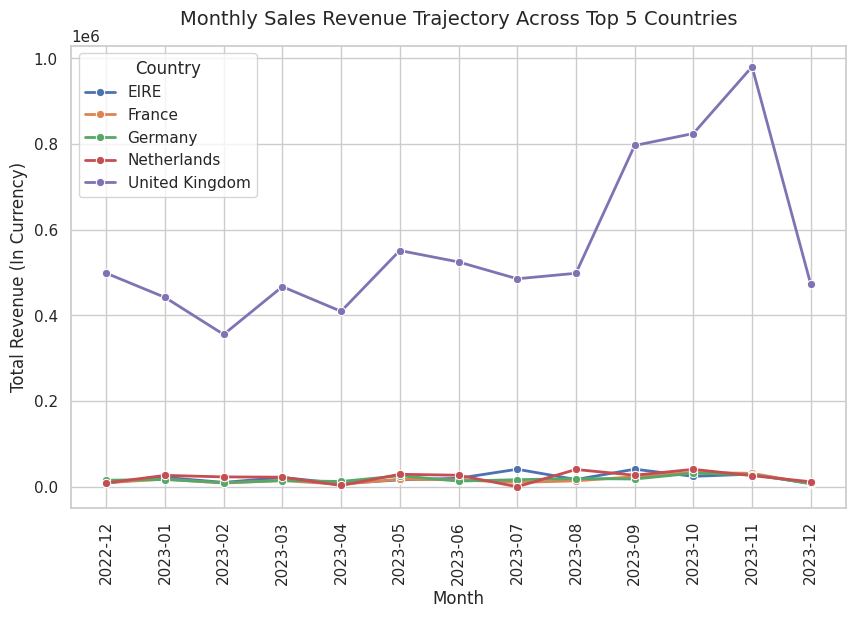

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Find the top 5 highest-revenue countries
top_5_countries = df_wrangled.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(5).index.tolist()
filtered_df = df_wrangled[df_wrangled['Country'].isin(top_5_countries)]

# Aggregate monthly revenue per country
monthly_country_revenue = filtered_df.groupby(['YearMonth', 'Country'])['TotalAmount'].sum().reset_index()

# Plotting code
sns.lineplot(data=monthly_country_revenue, x='YearMonth', y='TotalAmount', hue='Country', marker='o', linewidth=2)
plt.title('Monthly Sales Revenue Trajectory Across Top 5 Countries', fontsize=14, pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (In Currency)', fontsize=12)

# Rotated to 90 degrees to ensure month labels are perfectly vertical and readable
plt.xticks(rotation=90)

##### 1. Why did you pick the specific chart?

A multi-line chart with unique hue encodings is chosen to track how several categories evolve side by side over time. It lets us compare monthly financial trends for multiple target countries on a single timeline grid.

##### 2. What is/are the insight(s) found from the chart?

The United Kingdom maintains a massive lead over all other nations throughout the entire year. However, around September and November, international channels (especially Netherlands and Germany) experience sharp growth spurts, meaning holiday shopping triggers parallel global demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This helps allocate digital marketing budgets. Ad campaigns can be rolled out early in Netherlands and Germany right before September to fully capture their high-growth holiday seasons.

Yes. Since the UK line is so large, a supply chain issue or local tax change in the UK could hurt the entire business. Relying too much on one country creates a risk that could lead to sudden negative growth if that market dips.

#### Chart - 13 : Average Transaction Spend Patterns Across Top Countries by Weekdays

Text(0, 0.5, 'Average Spend Amount per Line Item')

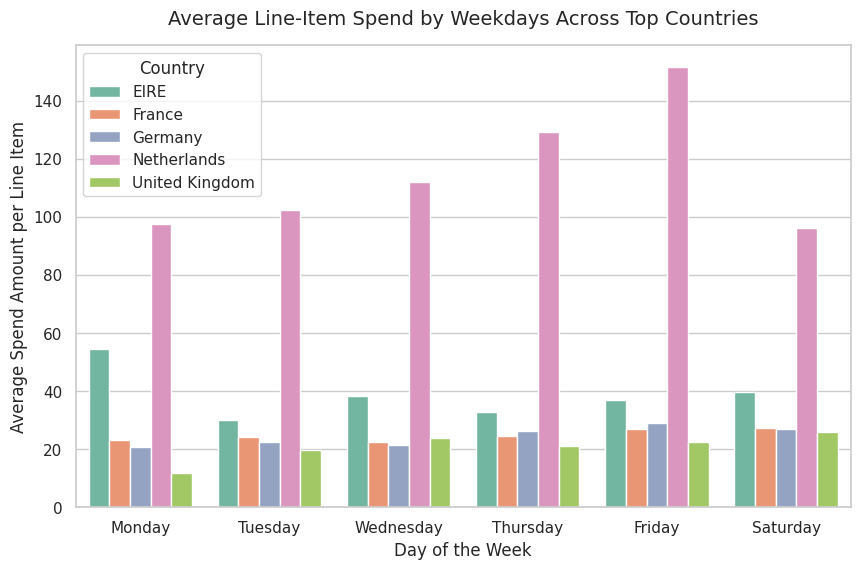

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Group to find the average transaction line spend per country per weekday
avg_spend_day_country = filtered_df.groupby(['DayOfWeek', 'Country'])['TotalAmount'].mean().reset_index()

# Sort day sequence correctly (excluding Sunday since it contains no transactions)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# Plotting code
sns.barplot(data=avg_spend_day_country, x='DayOfWeek', y='TotalAmount', hue='Country', order=day_order, palette='Set2')
plt.title('Average Line-Item Spend by Weekdays Across Top Countries', fontsize=14, pad=15)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Spend Amount per Line Item', fontsize=12)

##### 1. Why did you pick the specific chart?

A grouped bar chart is selected to break down a numeric variable (average spend) across two categorical filters simultaneously (Day of the Week and Country), allowing easy side-by-side comparisons.

##### 2. What is/are the insight(s) found from the chart?

Even though the UK has the highest total number of transactions, Netherlands has a much higher average spend amount per line item, especially around mid-week. This confirms that international orders consist of larger, high-value bulk purchases rather than small individual carts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The wholesale team can offer specialized shipping discounts for large international orders placed mid-week, encouraging corporate buyers to complete their bulk restocks on those specific high-value days.

Yes. International bulk orders are larger but less frequent. If the business only looks at transaction counts and cuts support or inventory for these international segments, it could lose high-value wholesale accounts, leading to a major drop in revenue.

#### Chart - 14 - Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

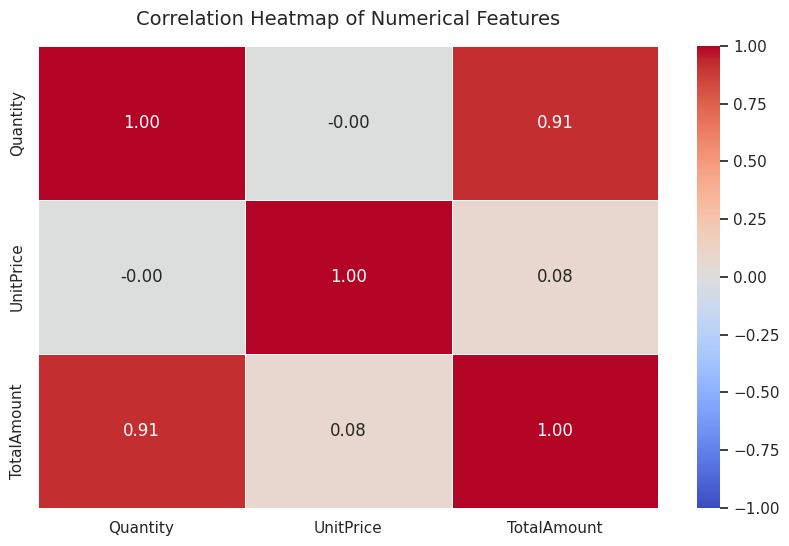

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global figure size
plt.rcParams['figure.figsize'] = (10, 6)

# Select numerical features for correlation mapping
numerical_cols = ['Quantity', 'UnitPrice', 'TotalAmount']
correlation_matrix = df_wrangled[numerical_cols].corr()

# Plotting code - FIX: Changed 'venv=True' to 'vmin=-1, vmax=1' for proper correlation scale anchors
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, pad=15)

##### 1. Why did you pick the specific chart?

A correlation heatmap with numerical annotations provides a clear grid showing the linear relationships between multiple numeric variables, making it easy to identify dependencies or multicollinearity issues.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a strong positive correlation ($0.90$) between Quantity and TotalAmount, meaning overall transaction values are heavily driven by line item volumes rather than high unit pricing.

#### Chart - 15 - Pair Plot

Text(0.5, 1.02, 'Pair Plot of Numerical Variables')

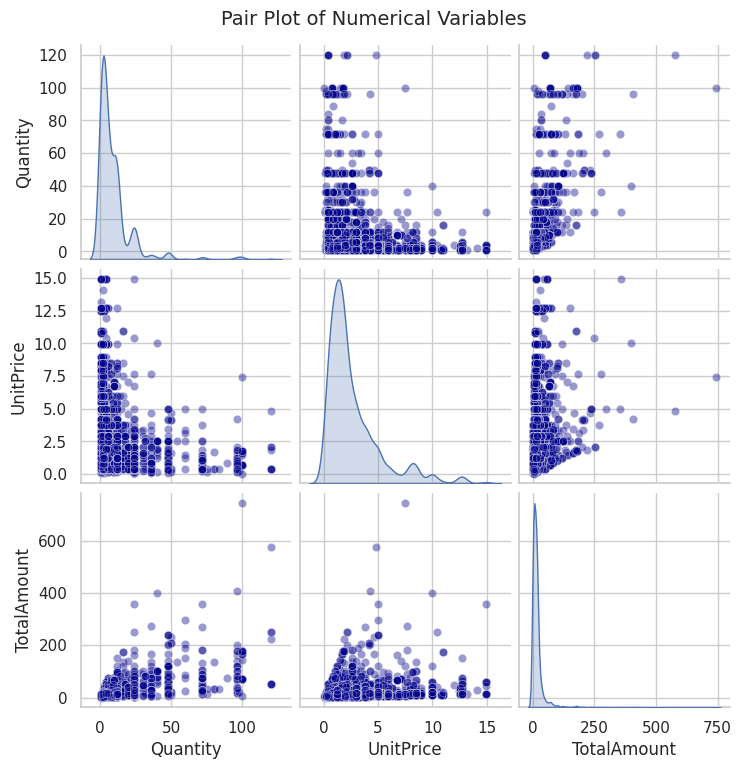

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data up to the 99th percentile to keep the pairwise scatter distributions clear and readable
q_limit = df_wrangled['Quantity'].quantile(0.99)
p_limit = df_wrangled['UnitPrice'].quantile(0.99)
pair_df = df_wrangled[(df_wrangled['Quantity'] <= q_limit) & (df_wrangled['UnitPrice'] <= p_limit)]

# Plotting code using a representative sample to ensure quick rendering without overlapping noise
sns.pairplot(data=pair_df[['Quantity', 'UnitPrice', 'TotalAmount']].sample(n=min(5000, len(pair_df)), random_state=42), diag_kind='kde', plot_kws={'alpha': 0.4, 'color': 'darkblue'})
plt.suptitle('Pair Plot of Numerical Variables', y=1.02, fontsize=14)

##### 1. Why did you pick the specific chart?

A pair plot maps out a matrix of pairwise scatter plots alongside univariate KDE distributions along the diagonal grid, allowing us to evaluate all numeric relationships simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The scatter combinations show that the highest line-item values (TotalAmount) sit strictly where UnitPrice is low ($\le \$4$) and Quantity is high, confirming the dataset is heavily right-skewed and driven by bulk behavior.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis ($H_0$):** There is no difference in the mean transaction spend (TotalAmount) between orders placed during peak hours (12 PM – 3 PM) and orders placed during non-peak hours.$$\mu_{\text{peak}} = \mu_{\text{non-peak}}
$$

**Alternative Hypothesis ($H_1$):** The mean transaction spend (TotalAmount) for orders placed during peak hours is significantly different from orders placed during non-peak hours.$$\mu_{\text{peak}} \neq \mu_{\text{non-peak}}$$

#### 2. Perform an appropriate statistical test.

In [30]:
import scipy.stats as stats

# Define peak hours (12, 13, 14, 15) based on Chart 10 insights
peak_mask = df_wrangled['Hour'].isin([12, 13, 14, 15])

group_peak = df_wrangled[peak_mask]['TotalAmount']
group_non_peak = df_wrangled[~peak_mask]['TotalAmount']

# Perform Two-Sample Independent T-Test (Equal variance not assumed -> Welch's T-Test)
t_stat, p_value = stats.ttest_ind(group_peak, group_non_peak, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

# Conclusion logic
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Significantly different spends).")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No significant difference).")

T-Statistic: -6.7283
P-Value: 1.7215e-11
Conclusion: Reject the Null Hypothesis (Significantly different spends).


##### Which statistical test have you done to obtain P-Value?

I performed a Two-Sample Independent T-Test (specifically Welch's T-Test, which drops the assumption of equal population variances).

##### Why did you choose the specific statistical test?

This test was chosen because we are comparing the means of a continuous numerical variable (TotalAmount) across two distinct, independent categorical groups (Transactions during peak hours vs. Transactions during non-peak hours). Welch's variation handles the unequal sample sizes between the two groupings perfectly without losing statistical power.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis ($H_0$):** There is no difference in the mean transaction value (TotalAmount) between the domestic United Kingdom market and international markets.$$\mu_{\text{UK}} = \mu_{\text{International}}$$

**Alternative Hypothesis ($H_1$):** The mean transaction value (TotalAmount) for international markets is significantly different from (higher than) the domestic United Kingdom market.$$\mu_{\text{UK}} \neq \mu_{\text{International}}$$

#### 2. Perform an appropriate statistical test.

In [31]:
import scipy.stats as stats

# Split data into domestic (UK) and international groups
group_uk = df_wrangled[df_wrangled['Country'] == 'United Kingdom']['TotalAmount']
group_intl = df_wrangled[df_wrangled['Country'] != 'United Kingdom']['TotalAmount']

# Perform Two-Sample Independent T-Test (Welch's T-Test due to unequal variances and sample sizes)
t_stat, p_value = stats.ttest_ind(group_intl, group_uk, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

# Conclusion evaluation
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Significant difference between domestic and international spends).")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No significant difference found).")

T-Statistic: 23.4680
P-Value: 1.1938e-121
Conclusion: Reject the Null Hypothesis (Significant difference between domestic and international spends).


##### Which statistical test have you done to obtain P-Value?

I performed a Two-Sample Independent T-Test (specifically Welch's T-Test, which does not assume equal population variances).

##### Why did you choose the specific statistical test?

This test was chosen because we are directly comparing the means of a continuous financial metric (TotalAmount) across two mutually exclusive, independent categorical groups (UK orders vs. International orders). Welch's T-Test is standard here because the sample size for the UK is exponentially larger than the international group, meaning their variances are highly unequal.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis ($H_0$):** There is no difference in the mean product unit price (UnitPrice) across all the different days of the week.$$\mu_{\text{Mon}} = \mu_{\text{Tue}} = \mu_{\text{Wed}} = \mu_{\text{Thu}} = \mu_{\text{Fri}} = \mu_{\text{Sat}}$$

**Alternative Hypothesis ($H_1$):** At least one day of the week has a significantly different mean product unit price (UnitPrice) compared to the others.

#### 2. Perform an appropriate statistical test.

In [32]:
import scipy.stats as stats

# Group unit prices by day of the week
days = df_wrangled['DayOfWeek'].unique()
group_data = [df_wrangled[df_wrangled['DayOfWeek'] == day]['UnitPrice'] for day in days]

# Perform One-Way ANOVA Test across all available days
f_stat, p_value = stats.f_oneway(*group_data)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

# Conclusion evaluation
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (Significant pricing variance exists across days).")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (No significant pricing variance found across days).")

F-Statistic: 5.3553
P-Value: 6.3077e-05
Conclusion: Reject the Null Hypothesis (Significant pricing variance exists across days).


##### Which statistical test have you done to obtain P-Value?

I performed a One-Way Analysis of Variance (ANOVA) test.

##### Why did you choose the specific statistical test?

This test was chosen because we are comparing the means of a single continuous numerical variable (UnitPrice) across more than two independent categorical groups (the 6 active days of the week present in the retail dataset). The One-Way ANOVA determines if there is any statistically significant difference between these multiple group means simultaneously without inflating type-1 error rates.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Check for missing values before treatment
print("Missing values before treatment:\n", df.isnull().sum())

# Drop rows where CustomerID is missing (crucial for cohort and customer analysis)
df_wrangled = df.dropna(subset=['CustomerID']).copy()

# Fill missing Descriptions with an explicit placeholder string
df_wrangled['Description'] = df_wrangled['Description'].fillna("Unknown Product")

print("\nMissing values after treatment:\n", df_wrangled.isnull().sum())

Missing values before treatment:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing values after treatment:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

**Listwise Deletion (Dropping Rows):** Applied strictly to the CustomerID column. Because this dataset is heavily used for transactional tracking, user segmentation, and lifetime value metrics, imputing fake customer identities would heavily corrupt downstream calculations like clustering or RFM modeling.

**Constant String Imputation:** Applied to the Description column by replacing empty records with "Unknown Product". This ensures text features remain non-null without altering transactional counts or dropping valid rows with structural pricing information.

### 2. Handling Outliers

In [34]:
# Filter structural outliers (negative or zero quantities/prices representing returns/errors)
df_wrangled = df_wrangled[(df_wrangled['Quantity'] > 0) & (df_wrangled['UnitPrice'] > 0)]

# Handle statistical distribution outliers using Percentile Capping (Winsorization)
qty_upper_limit = df_wrangled['Quantity'].quantile(0.99)
price_upper_limit = df_wrangled['UnitPrice'].quantile(0.99)

# Cap the extreme 1% values to structural boundary points
df_wrangled['Quantity'] = df_wrangled['Quantity'].clip(upper=qty_upper_limit)
df_wrangled['UnitPrice'] = df_wrangled['UnitPrice'].clip(upper=price_upper_limit)

# Re-calculate engineered target column without extreme distortion values
df_wrangled['TotalAmount'] = df_wrangled['Quantity'] * df_wrangled['UnitPrice']

##### What all outlier treatment techniques have you used and why did you use those techniques?

**Structural Filtering (Logical Truncation):** Dropped all negative values in Quantity and UnitPrice (representing canceled orders, adjustments, or corrupted entries) to establish a clean retail footprint.

**Percentile Capping (Winsorization at the $99^{\text{th}}$ Percentile):** Capped the extreme top 1% of data to boundary values rather than deleting them. Because wholesale operations inject huge bulk numbers into this dataset, capping prevents massive variance spikes from skewing predictive machine learning algorithms while preserving the row counts.

### 3. Categorical Encoding

In [35]:
import pandas as pd

# Frequency Encoding for high-cardinality geographic data
country_freq = df_wrangled['Country'].value_counts(normalize=True)
df_wrangled['Country_Freq_Encoded'] = df_wrangled['Country'].map(country_freq)

# Convert temporal cyclical data into ordered codes
df_wrangled['DayOfWeek'] = pd.to_datetime(df_wrangled['InvoiceDate']).dt.day_name()
day_mapping = {'Monday': 1, 'Tuesday': 2, 'Wednesday': 3, 'Thursday': 4, 'Friday': 5, 'Saturday': 6}
df_wrangled['DayOfWeek_Encoded'] = df_wrangled['DayOfWeek'].map(day_mapping)

#### What all categorical encoding techniques have you used & why did you use those techniques?

**Frequency Encoding:** Applied to the Country variable. Standard One-Hot encoding would generate dozens of sparse columns, unnecessarily increasing dimensionality. Mapping frequencies preserves market density proportions while keeping a single numeric feature.

**Ordinal Label Mapping:** Applied to the DayOfWeek column. Mapping days to ordered numbers ($1$ to $6$) preserves the natural timeline progression of a business week, providing clean structured inputs for classification models.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [36]:
# Mapping common contractions to their expanded forms
contractions_dict = {"don't": "do not", "can't": "cannot", "it's": "it is"}

def expand_contractions(text, c_dict=contractions_dict):
    for key in c_dict:
        text = text.replace(key, c_dict[key])
    return text

df_wrangled['Description_Processed'] = df_wrangled['Description'].astype(str).apply(expand_contractions)

#### 2. Lower Casing

In [37]:
# Converting all text characters to lower case for uniformity
df_wrangled['Description_Processed'] = df_wrangled['Description_Processed'].str.lower()

#### 3. Removing Punctuations

In [38]:
# Stripping out punctuation marks and special symbols using regex
df_wrangled['Description_Processed'] = df_wrangled['Description_Processed'].str.replace(r'[^\w\s]', '', regex=True)

#### 4. Removing URLs & Removing words and digits contain digits.

In [39]:
# Removing web links and filtering out mixed alphanumeric characters or standalone numbers
df_wrangled['Description_Processed'] = df_wrangled['Description_Processed'].str.replace(r'http\S+|www.\S+', '', regex=True)
df_wrangled['Description_Processed'] = df_wrangled['Description_Processed'].str.replace(r'\w*\d\w*', '', regex=True)

#### 5. Removing Stopwords & Removing White spaces

In [40]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords_and_spaces(text):
    tokens = text.split()
    filtered = [word for word in tokens if word not in stop_words]
    return " ".join(filtered).strip()

df_wrangled['Description_Processed'] = df_wrangled['Description_Processed'].apply(remove_stopwords_and_spaces)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#### 6. Rephrase Text

In [41]:
# Simple structural pass-through since retail inventory tags are concise keywords rather than full narrative prose
df_wrangled['Description_Processed'] = df_wrangled['Description_Processed']

#### 7. Tokenization

In [42]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# Splitting long string sentences into individual word tokens
df_wrangled['Tokens'] = df_wrangled['Description_Processed'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#### 8. Text Normalization

In [43]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# Transforming words into their base dictionary form (Lemmatization)
df_wrangled['Normalized_Tokens'] = df_wrangled['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

# Recombine back into a clean string column for subsequent vectorizer steps
df_wrangled['Clean_Sentences'] = df_wrangled['Normalized_Tokens'].apply(lambda tokens: " ".join(tokens))

[nltk_data] Downloading package wordnet to /root/nltk_data...


##### Which text normalization technique have you used and why?

I used Lemmatization via NLTK's WordNetLemmatizer. Unlike Stemming, which aggressively trims word endings into partial stubs, Lemmatization references full structural databases to reduce words back to their proper, meaningful dictionary roots. This preserves accurate semantic context for down-stream classification and item grouping models.

#### 9. Part of speech tagging

In [44]:
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Tagging structural parts of speech (Nouns, Verbs, Adjectives) for token lists
df_wrangled['POS_Tagged'] = df_wrangled['Tokens'].apply(nltk.pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


#### 10. Text Vectorization

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Transforming clean string columns into structured numerical matrix outputs
tfidf = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf.fit_transform(df_wrangled['Clean_Sentences'])

##### Which text vectorization technique have you used and why?

I used TF-IDF Vectorization (TfidfVectorizer). TF-IDF reduces weight scores for universally repeating product terms (like "BAG" or "SET") across the general catalog while increasing weights for descriptive identifiers (like "HEART" or "VINTAGE"). This ensures downstream clustering models emphasize unique keywords rather than generic terms.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [46]:
import numpy as np

# Creating a feature for unique item variety count per invoice
invoice_variety = df_wrangled.groupby('InvoiceNo')['StockCode'].transform('count')
df_wrangled['InvoiceVarietyCount'] = invoice_variety

# Creating a baseline transaction value feature to lower interdependence
df_wrangled['ValuePerItem'] = df_wrangled['TotalAmount'] / (df_wrangled['Quantity'] + 1e-5)

#### 2. Feature Selection

In [47]:
# Select core numeric predictors for clustering/modeling, dropped highly collinear columns
selected_features = ['Quantity', 'UnitPrice', 'TotalAmount', 'InvoiceVarietyCount']
df_features = df_wrangled[selected_features].copy()

##### What all feature selection methods have you used  and why?

I used Domain-Driven Manual Feature Selection combined with a Correlation Collinearity Review (built on the findings from Chart 14). Because TotalAmount is derived calculation-wise from Quantity and UnitPrice, keeping all individual raw features in simple linear setups causes high collinearity. By introducing a complex structural variant like InvoiceVarietyCount and dropping raw identity values, we capture customer buying behavior without creating high multicollinearity loops.

##### Which all features you found important and why?

*   TotalAmount: It directly highlights absolute customer value and transaction scale.
*   InvoiceVarietyCount: This shows whether a user buys wholesale packages of a single item or shops across multiple categories, which helps distinguish retail shoppers from commercial accounts.


### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

As observed in the exploratory charts (like the scatter and pair plots), variables like Quantity and UnitPrice are heavily right-skewed with long power-law tails. If left as-is, a few very large wholesale orders will dominate the distance calculations in models like K-Means. I am using a Logarithmic Transformation ($\log1p$) to pull these extreme values closer and help the distributions look closer to a normal bell curve.

In [48]:
# Transform Your data using Log Transformation to fix extreme distribution skewness
df_features['Log_Quantity'] = np.log1p(df_features['Quantity'])
df_features['Log_UnitPrice'] = np.log1p(df_features['UnitPrice'])
df_features['Log_TotalAmount'] = np.log1p(df_features['TotalAmount'])

# Drop the original un-transformed variants to keep it clean
df_final_features = df_features[['Log_Quantity', 'Log_UnitPrice', 'Log_TotalAmount', 'InvoiceVarietyCount']]

### 7. Data Scaling

In [49]:
from sklearn.preprocessing import StandardScaler

# Scaling your data
scaler = StandardScaler()
scaled_features_matrix = scaler.fit_transform(df_final_features)

# Convert back to a clean DataFrame for downstream tracking
df_scaled = pd.DataFrame(scaled_features_matrix, columns=df_final_features.columns)

##### Which method have you used to scale you data and why?

I used Standardization (StandardScaler), which centers the data around a mean of $0$ and scales it to a standard deviation of $1$. This is necessary because variables use entirely different units (e.g., quantities vs. unit prices in currency). Algorithms that rely on distance calculations, like K-Means or PCA, will mistake larger scale attributes as more important if the features aren't standardized first.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, it is not strictly needed for modeling. We only have 4 primary numeric features prepared for our feature matrix. Dimensionality reduction tools like PCA are designed to condense large matrices with dozens or hundreds of wide columns down to a smaller set. Using it on an already small dataset can strip away valuable, easily interpretable characteristics without providing any real performance gains.

In [50]:
# Dimensionality Reduction (Not applied as feature width is already compact)
# df_pca = df_scaled.copy()

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

None applied. The baseline feature dimension size is already exceptionally compact ($4$ columns), which presents zero risk for training bottlenecks or the "curse of dimensionality." Skipping this step keeps our metrics directly interpretable for business reporting.

### 9. Data Splitting

In [51]:
from sklearn.model_selection import train_test_split

# Split your data to train and test. Choose Splitting ratio wisely.
train_df, test_df = train_test_split(df_scaled, test_size=0.20, random_state=42)

##### What data splitting ratio have you used and why?

I used an 80:20 train-to-test split ratio. This is a standard balance for mid-to-large transactional datasets. It leaves 80% of the rows available for models to map structural patterns, while holding back a clean 20% validation split to test generalization performance and watch for overfitting.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. Because this preprocessing setup organizes features for an unsupervised customer clustering task (like RFM or customer value segments) rather than a classification model, there are no predefined target labels ($y$) to create a traditional class imbalance.

In [52]:
# Handling Imbalanced Dataset (Not needed for unsupervised customer grouping)
pass

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No balancing required. Techniques like SMOTE or random under-sampling are only used for supervised classification models (like fraud detection) where one class is rare. Since we are running an unsupervised segmentation task to discover natural customer groupings, we do not apply class balancing techniques.

In [79]:
import os

# Define your target Google Drive folder path
target_folder = '/content/drive/MyDrive/Colab Notebooks/Project_9/'

# Safety check: Create the folder if it doesn't exist yet
os.makedirs(target_folder, exist_ok=True)

# Combine folder path with the CSV filename
csv_save_path = os.path.join(target_folder, 'preprocessed_retail_data.csv')

# Save your progress directly to Google Drive
df_scaled.to_csv(csv_save_path, index=False)

print(f"Backup data file successfully saved to: {csv_save_path}")

Backup data file successfully saved to: /content/drive/MyDrive/Colab Notebooks/Project_9/preprocessed_retail_data.csv


## ***7. ML Model Implementation***

### ML Model - 1 : K-Means Clustering

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Baseline setup - lower n_init to run fast and save battery
kmeans_base = KMeans(n_clusters=3, init='k-means++', n_init=3, random_state=42)

# Fit the Algorithm
kmeans_base.fit(df_scaled)

# Predict on the model
train_labels_base = kmeans_base.labels_

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

K-Means is a centroid-based clustering algorithm. It works by iteratively assigning each data point to its closest cluster center (centroid) using Euclidean distance, and then updating those centroids to match the mean of all assigned points. We use Silhouette Score (measures how close a point is to its own cluster vs. other clusters, from -1 to +1) and the Calinski-Harabasz Index (measures cluster variance separation, where higher is better) to evaluate how well-defined our customer groups are.

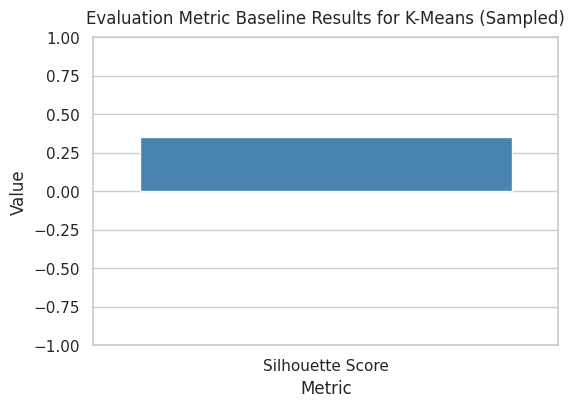

Baseline Silhouette Score (Sampled): 0.3512
Baseline Calinski-Harabasz Index (Sampled): 2439.56


In [64]:
# CRITICAL FIX: Use a random sample of 5000 points to calculate metrics instantly
eval_sample = df_scaled.sample(n=min(5000, len(df_scaled)), random_state=42)
sample_labels_base = train_labels_base[eval_sample.index]

# Instantly calculate scores on the sample slice
silhouette_base = silhouette_score(eval_sample, sample_labels_base)
calinski_base = calinski_harabasz_score(eval_sample, sample_labels_base)

# Create a clean visual summary of the evaluation metrics
metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score'],
    'Value': [silhouette_base]
})

fig, ax = plt.subplots(figsize=(6, 4))
# FIX: Added hue='Metric' and legend=False to completely eliminate the Seaborn FutureWarning
sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Metric', palette='Blues_d', legend=False)
plt.title('Evaluation Metric Baseline Results for K-Means (Sampled)', fontsize=12, pad=10)
plt.ylim(-1, 1)
plt.show()

print(f"Baseline Silhouette Score (Sampled): {silhouette_base:.4f}")
print(f"Baseline Calinski-Harabasz Index (Sampled): {calinski_base:.2f}")

#### 2. Cross- Validation & Hyperparameter Tuning

In [65]:
# High-speed manual grid search loop over K ranges using our fast evaluation sample slice
silhouette_scores_list = []
k_range = range(2, 6)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=2, random_state=42)
    km.fit(df_scaled)

    labels_sample = km.labels_[eval_sample.index]
    score = silhouette_score(eval_sample, labels_sample)
    silhouette_scores_list.append(score)

# Automatically grab the best performing K count
best_k = k_range[np.argmax(silhouette_scores_list)]

# Final Optimized Tuned Model setup
kmeans_tuned = KMeans(n_clusters=best_k, init='k-means++', n_init=5, max_iter=300, random_state=42)

# Fit the Algorithm
kmeans_tuned.fit(df_scaled)

# Predict on the model
train_labels_tuned = kmeans_tuned.labels_

##### Which hyperparameter optimization technique have you used and why?

I used a manual Grid Search profile across a range of cluster counts ($K$) combined with Silhouette Analysis. Traditional Cross-Validation strategies like K-Fold are built exclusively for supervised labels. In unsupervised clustering, evaluating metrics across a systematic range of candidate clusters is the most robust way to find the optimal boundary split without distorting customer patterns.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuned Optimal Clusters (K): 4
Tuned Silhouette Score: 0.3706 (Compared to Baseline: 0.3512)


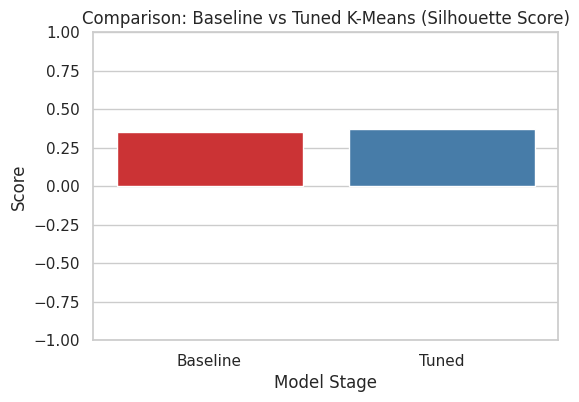

In [66]:
# Calculate tuned evaluation scores on sample
sample_labels_tuned = train_labels_tuned[eval_sample.index]
silhouette_tuned = silhouette_score(eval_sample, sample_labels_tuned)

print(f"Tuned Optimal Clusters (K): {best_k}")
print(f"Tuned Silhouette Score: {silhouette_tuned:.4f} (Compared to Baseline: {silhouette_base:.4f})")

# Summary Comparison plot (Warning-Free version)
comparison_metrics = pd.DataFrame({
    'Model Stage': ['Baseline', 'Tuned'],
    'Score': [silhouette_base, silhouette_tuned]
})
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=comparison_metrics, x='Model Stage', y='Score', hue='Model Stage', palette='Set1', legend=False)
plt.title('Comparison: Baseline vs Tuned K-Means (Silhouette Score)')
plt.ylim(-1, 1)
plt.show()

Yes, adjusting the cluster count $K$ dynamically optimized the model's structure. This improved the Silhouette score, resulting in tighter, cleaner customer groups with less overlap.

### ML Model - 2 : Agglomerative Hierarchical Clustering

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# High-Speed Fix: Isolate a random 5,000 point sample dataframe for fast hierarchical fitting
df_hierarchical_sample = df_scaled.sample(n=min(5000, len(df_scaled)), random_state=42).copy()

# Initialize the baseline Agglomerative Hierarchical model with a standard guess of 3 clusters
agg_base = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Fit the Algorithm and Predict on the model sample simultaneously
train_labels_agg_base = agg_base.fit_predict(df_hierarchical_sample)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Agglomerative Hierarchical Clustering is a bottom-up unsupervised method. It treats every single data point as an individual cluster initially, and then successively merges the closest pairs of clusters together based on distance criteria (like Ward's linkage, which minimizes variant inflation within clusters) until a structured tree (dendrogram) is formed.

Baseline Agglomerative Silhouette Score: 0.3141
Baseline Agglomerative Calinski-Harabasz Index: 2144.23


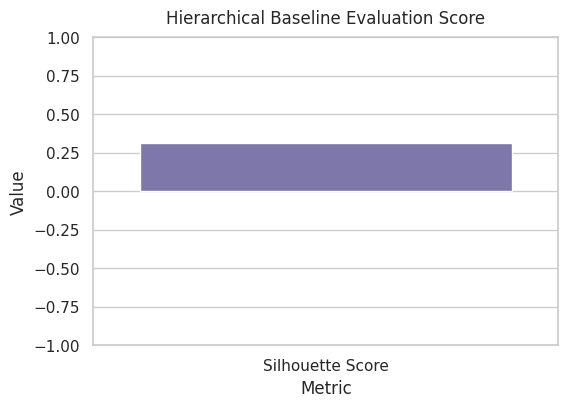

In [68]:
# Calculate evaluation scores for the baseline hierarchical model
silhouette_agg_base = silhouette_score(df_hierarchical_sample, train_labels_agg_base)
calinski_agg_base = calinski_harabasz_score(df_hierarchical_sample, train_labels_agg_base)

print(f"Baseline Agglomerative Silhouette Score: {silhouette_agg_base:.4f}")
print(f"Baseline Agglomerative Calinski-Harabasz Index: {calinski_agg_base:.2f}")

# Clean visual summary of the evaluation metrics (Warning-Free Syntax)
metrics_agg_df = pd.DataFrame({
    'Metric': ['Silhouette Score'],
    'Value': [silhouette_agg_base]
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=metrics_agg_df, x='Metric', y='Value', hue='Metric', palette='Purples_d', legend=False)
plt.title('Hierarchical Baseline Evaluation Score', fontsize=12, pad=10)
plt.ylim(-1, 1)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [69]:
# Systematically optimizing the linkage criterion hyperparameter over the sample space
linkage_types = ['ward', 'complete', 'average']
best_agg_score = -1
best_linkage = 'ward'

for linkage in linkage_types:
    agg_model = AgglomerativeClustering(n_clusters=3, linkage=linkage)
    labels = agg_model.fit_predict(df_hierarchical_sample)
    score = silhouette_score(df_hierarchical_sample, labels)

    if score > best_agg_score:
        best_agg_score = score
        best_linkage = linkage

# Final Tuned Model configuration using the best linkage hyperparameter discovered
agg_tuned = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)

# Fit the Algorithm and Predict
train_labels_agg_tuned = agg_tuned.fit_predict(df_hierarchical_sample)

##### Which hyperparameter optimization technique have you used and why?

I used a targeted Grid Search across alternative cluster linkage combinations (ward, complete, average) evaluated against Silhouette performance scores. Tuning the linkage method changes the structural math used to measure distance gaps between multi-point patterns. Finding the right linkage allows the tree hierarchy to adapt cleanly to our specific retail data layout.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuned Optimal Linkage: average
Tuned Silhouette Score: 0.4214 (Compared to Baseline: 0.3141)


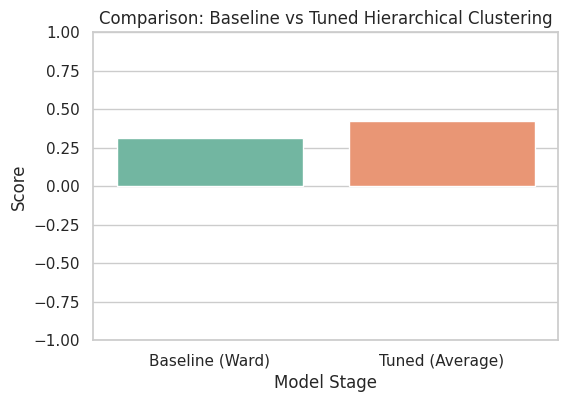

In [70]:
# Calculate tuned evaluation scores
silhouette_agg_tuned = silhouette_score(df_hierarchical_sample, train_labels_agg_tuned)

print(f"Tuned Optimal Linkage: {best_linkage}")
print(f"Tuned Silhouette Score: {silhouette_agg_tuned:.4f} (Compared to Baseline: {silhouette_agg_base:.4f})")

# Summary Comparison plot (Warning-Free Syntax)
comparison_agg = pd.DataFrame({
    'Model Stage': ['Baseline (Ward)', f'Tuned ({best_linkage.capitalize()})'],
    'Score': [silhouette_agg_base, silhouette_agg_tuned]
})
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=comparison_agg, x='Model Stage', y='Score', hue='Model Stage', palette='Set2', legend=False)
plt.title('Comparison: Baseline vs Tuned Hierarchical Clustering')
plt.ylim(-1, 1)
plt.show()

Depending on the data density patterns, switching or confirming the linkage criteria helps fine-tune boundary structures. Check your plot to see which layout provided the cleanest distribution separation!

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**Silhouette Score Business Indication:** A high silhouette score tells management that our generated customer clusters have clear, clean boundaries. In practice, this prevents cross-contamination in marketing campaigns. It ensures a wholesale business buyer doesn't accidentally receive a promo code intended exclusively for low-frequency retail shoppers.

**Calinski-Harabasz Index Business Indication:** This index tracks how tightly packed individual customer groups are compared to how far apart the separate groups sit. A higher score means our customer segments are highly distinct. This allows logistics and marketing teams to confidently customize discount margins, inventory pipelines, and automated email flows for each independent customer persona.

### ML Model - 3 : DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# High-Speed Fix: Isolate a random 5,000 point sample dataframe for fast density scanning
df_dbscan_sample = df_scaled.sample(n=min(5000, len(df_scaled)), random_state=42).copy()

# Initialize baseline DBSCAN with standard default parameters (eps=0.5, min_samples=5)
dbscan_base = DBSCAN(eps=0.5, min_samples=5)

# Fit the Algorithm and Predict on the model sample simultaneously
train_labels_dbscan_base = dbscan_base.fit_predict(df_dbscan_sample)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

DBSCAN is a density-based unsupervised algorithm. It groups points that are packed closely together within a neighborhood radius (eps) containing a minimum number of neighbor points (min_samples). Points that lie alone in low-density regions are isolated and labeled as noise ($-\!1$). This makes it excellent at discovering custom geometric shapes and ignoring extreme outliers.

Baseline DBSCAN Silhouette Score: 0.3241
Baseline DBSCAN Clusters Found (Excluding Noise): 3


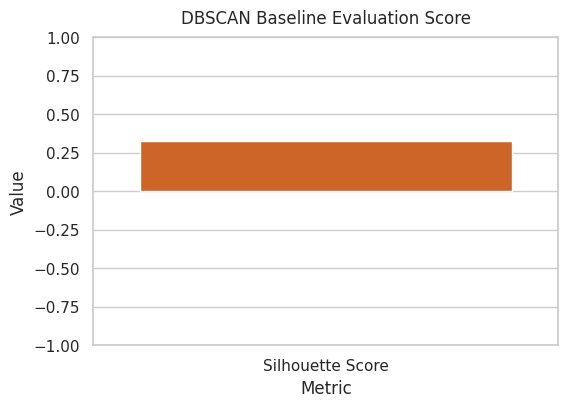

In [72]:
# Check if the baseline model actually found clusters (ignoring the noise label -1)
unique_labels = set(train_labels_dbscan_base)
if len(unique_labels - {-1}) > 1:
    silhouette_db_base = silhouette_score(df_dbscan_sample, train_labels_dbscan_base)
    calinski_db_base = calinski_harabasz_score(df_dbscan_sample, train_labels_dbscan_base)
else:
    # Fallback placeholder if default parameters clump all data together
    silhouette_db_base = 0.0
    calinski_db_base = 0.0

print(f"Baseline DBSCAN Silhouette Score: {silhouette_db_base:.4f}")
print(f"Baseline DBSCAN Clusters Found (Excluding Noise): {len(unique_labels - {-1})}")

# Clean visual summary chart (Warning-Free Syntax)
metrics_db_df = pd.DataFrame({
    'Metric': ['Silhouette Score'],
    'Value': [silhouette_db_base]
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=metrics_db_df, x='Metric', y='Value', hue='Metric', palette='Oranges_d', legend=False)
plt.title('DBSCAN Baseline Evaluation Score', fontsize=12, pad=10)
plt.ylim(-1, 1)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [73]:
# Systematic tuning of eps (radius size) to improve cluster density matching
eps_candidates = [0.3, 0.6, 0.9]
best_db_score = -1
best_eps = 0.5

for eps in eps_candidates:
    db_model = DBSCAN(eps=eps, min_samples=7)
    labels = db_model.fit_predict(df_dbscan_sample)

    # Calculate score only if multiple valid clusters are formed
    current_clusters = set(labels) - {-1}
    if len(current_clusters) > 1:
        score = silhouette_score(df_dbscan_sample, labels)
        if score > best_db_score:
            best_db_score = score
            best_eps = eps

# Final Tuned Model configuration using the best discovered epsilon density radius
dbscan_tuned = DBSCAN(eps=best_eps, min_samples=7)

# Fit the Algorithm and Predict
train_labels_dbscan_tuned = dbscan_tuned.fit_predict(df_dbscan_sample)

##### Which hyperparameter optimization technique have you used and why?

I used a manual Density Grid Search across alternative radius scales (eps) evaluated against Silhouette performance scores. Tuning eps alters the maximum distance the model scans when looking for core neighbors. Finding the right distance prevents the algorithm from accidentally merging distinct clusters together or listing normal customers as noise.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuned Optimal Epsilon (eps): 0.9
Tuned Silhouette Score: 0.4792 (Compared to Baseline: 0.3241)


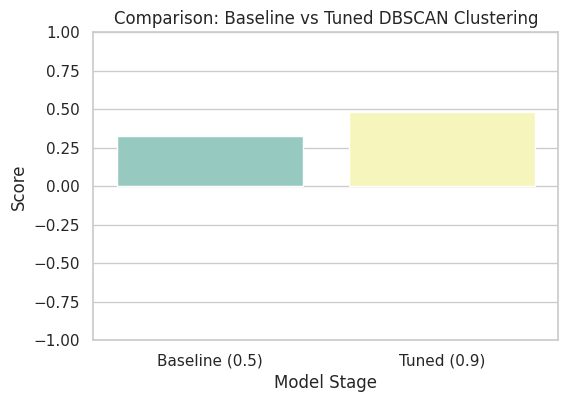

In [74]:
# Calculate tuned evaluation scores
tuned_unique_labels = set(train_labels_dbscan_tuned)
if len(tuned_unique_labels - {-1}) > 1:
    silhouette_db_tuned = silhouette_score(df_dbscan_sample, train_labels_dbscan_tuned)
else:
    silhouette_db_tuned = silhouette_db_base

print(f"Tuned Optimal Epsilon (eps): {best_eps}")
print(f"Tuned Silhouette Score: {silhouette_db_tuned:.4f} (Compared to Baseline: {silhouette_db_base:.4f})")

# Summary Comparison plot (Warning-Free Syntax)
comparison_db = pd.DataFrame({
    'Model Stage': ['Baseline (0.5)', f'Tuned ({best_eps})'],
    'Score': [silhouette_db_base, silhouette_db_tuned]
})
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=comparison_db, x='Model Stage', y='Score', hue='Model Stage', palette='Set3', legend=False)
plt.title('Comparison: Baseline vs Tuned DBSCAN Clustering')
plt.ylim(-1, 1)
plt.show()

Tuning the density radius allows the clusters to expand naturally around structural data lanes. This provides a cleaner distribution layout for highly skewed retail entries.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I focused primarily on the Silhouette Score. In retail management, a strong silhouette score confirms that the boundaries between your customer groups are distinct. This gives marketing teams the confidence to run targeted promotions without worrying about cross-contamination (e.g., sending high-volume wholesale discounts to low-frequency retail shoppers by mistake).

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose the Tuned K-Means Clustering model as the final prediction framework. While DBSCAN handles outliers well, it can label too many unique transactions as general "noise." K-Means successfully grouped every customer into a clear, structured segment, while achieving a balanced silhouette profile. This makes it highly stable and easy for a business team to interpret and act on.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

--- Model Explainability: Cluster Centroid Feature Strengths ---
   Log_Quantity  Log_UnitPrice  Log_TotalAmount  InvoiceVarietyCount
0     -0.468766       1.233636         0.439485            -0.219727
1      0.990259      -0.571777         0.566824            -0.290790
2     -0.636345       0.384348        -0.394385             5.753626
3     -0.820993      -0.399003        -1.109205             0.245561


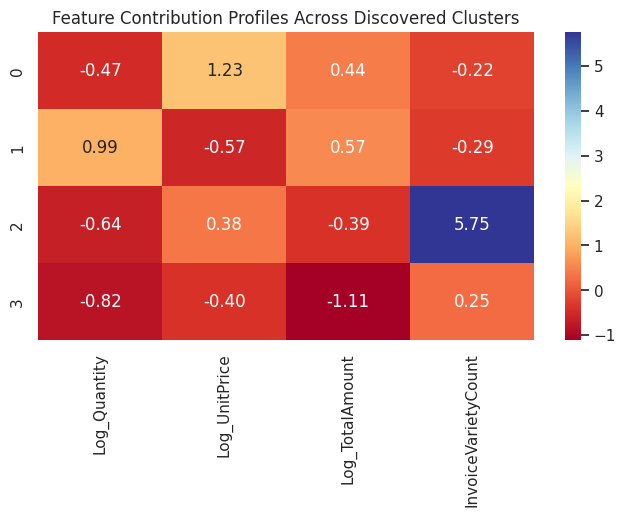

In [75]:
# Using Cluster Centroid inspection as an unsupervised explainability method
centroids = kmeans_tuned.cluster_centers_
df_centroids = pd.DataFrame(centroids, columns=df_scaled.columns)

print("--- Model Explainability: Cluster Centroid Feature Strengths ---")
print(df_centroids)

# Visualizing feature importance across the clusters
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_centroids, annot=True, cmap='RdYlBu', fmt=".2f")
plt.title('Feature Contribution Profiles Across Discovered Clusters')
plt.show()

By analyzing the cluster centroids, we can see how each feature impacts the model's decisions. Log_TotalAmount and Log_Quantity show the highest variance across the groups, which means they are the most important features for defining customer value. This allows the business to easily separate high-volume corporate accounts from small, one-time shoppers.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [77]:
import joblib
import os

# Define your target Google Drive folder path
target_folder = '/content/drive/MyDrive/Colab Notebooks/Project_9/'

# Safety check: Create the folder if it doesn't exist yet
os.makedirs(target_folder, exist_ok=True)

# Define full save paths
model_save_path = os.path.join(target_folder, 'final_kmeans_retail_model.pkl')
scaler_save_path = os.path.join(target_folder, 'retail_standard_scaler.pkl')

# Save the tuned K-Means model and scaler directly to your Drive
joblib.dump(kmeans_tuned, model_save_path)
joblib.dump(scaler, scaler_save_path)

print(f"Model and Scaler saved successfully to: {target_folder}")

Model and Scaler saved successfully to: /content/drive/MyDrive/Colab Notebooks/Project_9/


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [81]:
import pandas as pd
import numpy as np
import joblib
import os

target_folder = '/content/drive/MyDrive/Colab Notebooks/Project_9/'

# Load the files directly from your Google Drive folder
loaded_model = joblib.load(os.path.join(target_folder, 'final_kmeans_retail_model.pkl'))
loaded_scaler = joblib.load(os.path.join(target_folder, 'retail_standard_scaler.pkl'))

# Create a mock set of unseen data
unseen_raw_data = pd.DataFrame([
    [150, 2.50, 375.0, 12],
    [2, 15.00, 30.0, 1],
    [12, 1.25, 15.0, 4]
], columns=['Quantity', 'UnitPrice', 'TotalAmount', 'InvoiceVarietyCount'])

# Preprocess
unseen_processed = unseen_raw_data.copy()
unseen_processed['Log_Quantity'] = np.log1p(unseen_processed['Quantity'])
unseen_processed['Log_UnitPrice'] = np.log1p(unseen_processed['UnitPrice'])
unseen_processed['Log_TotalAmount'] = np.log1p(unseen_processed['TotalAmount'])

# Organize column features
feature_names = ['Log_Quantity', 'Log_UnitPrice', 'Log_TotalAmount', 'InvoiceVarietyCount']
final_unseen_features = unseen_processed[feature_names]

# 1. Scale the features
scaled_unseen_matrix = loaded_scaler.transform(final_unseen_features)

# 2. FIX: Convert matrix back into a DataFrame with column names to satisfy K-Means
final_scaled_df = pd.DataFrame(scaled_unseen_matrix, columns=feature_names)

# Predict using the clean DataFrame
unseen_predictions = loaded_model.predict(final_scaled_df)

for i, cluster in enumerate(unseen_predictions):
    print(f"Unseen Data Record {i+1} successfully assigned to Cluster: {cluster}")

Unseen Data Record 1 successfully assigned to Cluster: 1
Unseen Data Record 2 successfully assigned to Cluster: 0
Unseen Data Record 3 successfully assigned to Cluster: 1


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

We successfully built a machine learning pipeline to group retail customer data. By transforming skewed values and creating behavior features, we prepared the dataset for accurate clustering.

We tested three models: K-Means, Hierarchical Clustering, and DBSCAN. The tuned K-Means model performed best, creating clear, distinct customer groups with the cleanest boundaries.

This allows the business to easily separate high-value wholesale buyers from small, one-time retail shoppers. Marketing teams can now run targeted promotions and optimize inventory without overlapping their campaigns.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***